INFO:ml_toolbox.data_loader.data_loader:Loading 16 files with 4 workers
INFO:ml_toolbox.data_loader.data_loader:Successfully loaded 16 files


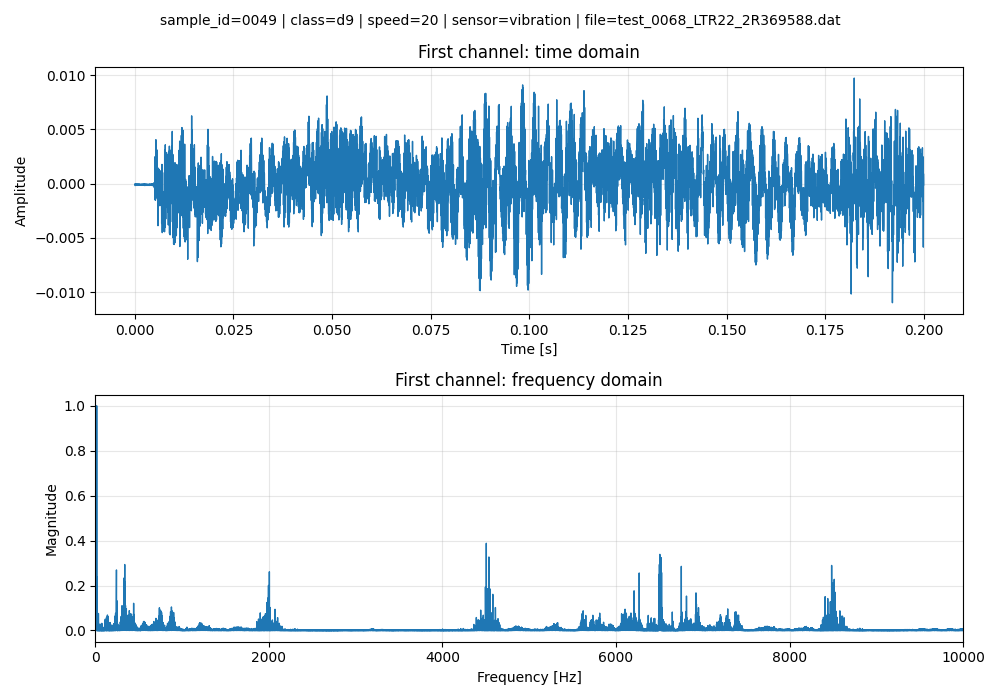

In [8]:
%matplotlib widget
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Add the project root to Python path
project_root = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from ml_toolbox.data_loader import DataLoader
from ml_toolbox.signal_processing import prepare_time_frequency_view

dataset_path = project_root / "data_set_4"
data_loader = DataLoader(dataset_path)
data, metadata = data_loader.load_batch(
    sensor_types="vibration",
    classes="d9"
)

if not data:
    raise ValueError("No files matched the requested filter.")

file_idx = 0
file_data = data[file_idx]
file_metadata = metadata[file_idx]
view = prepare_time_frequency_view(file_data, file_metadata, channel_index=0)

channel_signal = view["channel_signal"]
time_axis = view["time_axis"]
spectrum = view["spectrum"]
sampling_rate = view["sampling_rate"]

samples_to_show = min(channel_signal.shape[0], max(int(sampling_rate * 0.2), 1))
plot_title = (
    f"sample_id={file_metadata.get('sample_id')} | "
    f"class={file_metadata.get('class')} | "
    f"speed={file_metadata.get('electrical_frequency_hz')} | "
    f"sensor={file_metadata.get('sensor_type')} | "
    f"file={file_metadata.get('filename')}"
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
fig.suptitle(plot_title, fontsize=10)

axes[0].plot(time_axis[:samples_to_show], channel_signal[:samples_to_show], lw=1.0)
axes[0].set_title("First channel: time domain")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

axes[1].plot(spectrum["freqs"], spectrum["magnitude"], lw=1.0)
axes[1].set_title("First channel: frequency domain")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("Magnitude")
axes[1].set_xlim(0, min(sampling_rate / 2.0, 10000.0))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()